# Tutorial 6: Classification Analysis III

## Question 1:  Naive Bayes

Naive Bayes methods are a set of supervised learning algorithms based on applying Bayes’ theorem with the “naive” 
assumption of conditional independence between every pair of features given the value of the class variable. Bayes’ 
theorem states the following relationship, given class variable y and dependent feature vector $x_1$ through $x_n$ :

\begin{equation*}
P(y|x_1,x_2...x_n)=\frac{P(y)P(x_1,x2...x_n|y)}{P(x1,x2...x_n)}
\end{equation*}

\begin{equation*}
predicted y = \underset{y}{\operatorname{argmax}}  P(y)\prod_{i=1}^{n}P(x_i|y)
\end{equation*}

__Step 1: Generate Dataset:Use the same dataset in Tutorial 3 on Model Overfitting by generating class 0 and 1__

**<font color="red">Code:</font>**

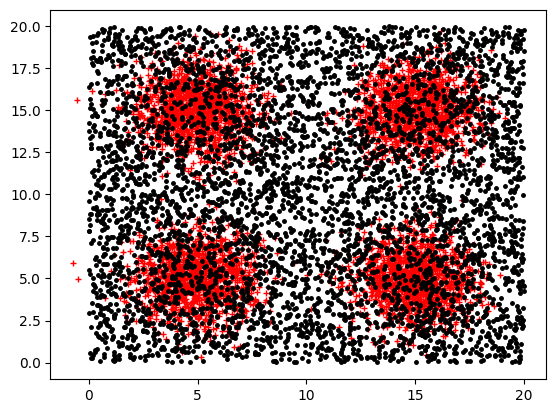

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.random import random

N = 10000               # number of data instances

mean1 = [5, 15]
mean2 = [15, 15]
mean3 = [15, 5]
mean4 = [5, 5]

cov = [[2, 0], [0, 2]]  # diagonal covariance

np.random.seed(500)
X = np.random.multivariate_normal(mean1, cov, int(N/8))                       # 1250 rows
X = np.concatenate((X, np.random.multivariate_normal(mean2, cov, int(N/8))))  # 1250 rows
X = np.concatenate((X, np.random.multivariate_normal(mean3, cov, int(N/8))))  # 1250 rows
X = np.concatenate((X, np.random.multivariate_normal(mean4, cov, int(N/8))))  # 1250 rows
X = np.concatenate((X, 20*np.random.rand(int(N/2),2)))                        # 5000 rows
Y = np.concatenate((np.ones(int(N/2)),np.zeros(int(N/2))))                    # 10000 class labels (1, 0)
plt.plot(X[:int(N/2),0],X[:int(N/2),1],'r+',X[int(N/2):,0],X[int(N/2):,1],'k.',ms=5)

__Step 2: Split into training and Test set in ratio of 70:30__
        
1)X_train: 70% of Original Data X
    
2)X_test : 30% of Original Data X
    
3)Y_train: 70% of Original Class Label Data Y 
    
4)Y_test : 30% of Original Class Label Data Y

**<font color="red">Code:</font>**

In [2]:
###########################################################
# Create the Training and Test set with split 70:30 
##########################################################

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=12)
from sklearn import tree
from sklearn.metrics import accuracy_score

__Step 3: Import GaussianNB from sklearn.naive_bayes__

1)find out the accuracy score between

i)Training accuracy : Y_train, Y_predTrain
    
ii)Test Accuracy : Y_test, Y_predTest
    
2)Plot Training Accuracy, Test Accuracy verus K values

**<font color="red">Code:</font>**

In [3]:
from sklearn.naive_bayes import GaussianNB

clf2=GaussianNB()
clf2.fit(X_train, Y_train)
Y_predTrain = clf2.predict(X_train)
Y_predTest = clf2.predict(X_test)
trainAcc=accuracy_score(Y_train, Y_predTrain)
testAcc=accuracy_score(Y_test, Y_predTest)
print("\nTraining Accuracy:",trainAcc)
print("\nTesting Accuracy:",testAcc)


Training Accuracy: 0.5855714285714285

Testing Accuracy: 0.574


Observation: The class prediction is only about half success. Why???

## Question 2:  Linear Prediction using Logistics Regression 

Linear classifiers such as logistic regression and support vector machine (SVM) constructs a linear separating 
hyperplane to distinguish instances from different classes. 

For logistic regression, the model can be described by the following equation:
\begin{equation*}
P(y=1|x) = \frac{1}{1 + \exp^{-w^Tx - b}} = \sigma(w^Tx + b)
\end{equation*}
The model parameters (w,b) are estimated by optimizing the following regularized negative log-likelihood function:
\begin{equation*}
(w^*,b^*) = \arg\min_{w,b} - \sum_{i=1}^N y_i \log\bigg[\sigma(w^Tx_i + b)\bigg] + (1-y_i) \log\bigg[1-\sigma(w^Tx_i + b)\bigg] + \frac{1}{C} \Omega([w,b])
\end{equation*}
where $C$ is a hyperparameter that controls the inverse of model complexity (smaller values imply stronger 
regularization) while $\Omega(\cdot)$ is the regularization term, which by default, is assumed to be an $l_2$-norm in sklearn.


__Step:__

1)Import linear model.LogisticRegession from sklearn

2)Set C range from 0.01,0.1,0.2,0.5,0.8,1,5,10,20,50

3)Repeat the same process of fitting with X_train and Y_train and predicting with X_train adn X_test

4)Calculate the accuracy score for testing and training prediction and plot verus various C

**<font color="red">Code:</font>**

Text(0, 0.5, 'Accuracy')

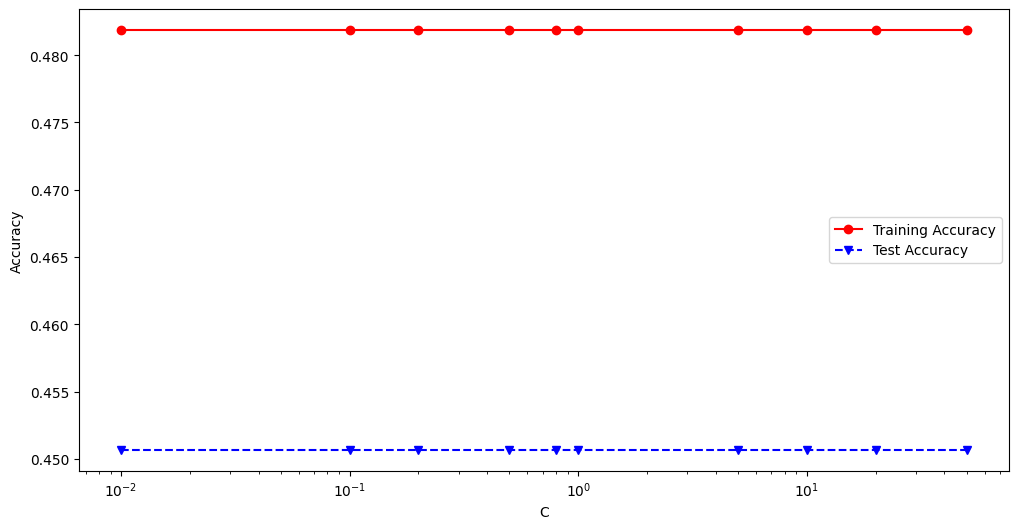

In [4]:
from sklearn import linear_model

C = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 20, 50]

LRtrainAcc = []
LRtestAcc = []

for param in C:
    clf3 = linear_model.LogisticRegression(C=param)
    clf3.fit(X_train, Y_train)
    Y_predTrain = clf3.predict(X_train)
    Y_predTest = clf3.predict(X_test)
    LRtrainAcc.append(accuracy_score(Y_train, Y_predTrain))
    LRtestAcc.append(accuracy_score(Y_test, Y_predTest))


fig, (ax1) = plt.subplots(1, 1, figsize=(12,6))
ax1.plot(C, LRtrainAcc, 'ro-', C, LRtestAcc,'bv--')
ax1.legend(['Training Accuracy','Test Accuracy'])
ax1.set_xlabel('C')
ax1.set_xscale('log')
ax1.set_ylabel('Accuracy')


Observation:Note that linear classifiers perform poorly on the data since the true decision boundaries between 
classes are nonlinear for the given 2-dimensional dataset. Can you visualize?